In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
file_path = 'laptop_prices.csv'
print(f"Found '{file_path}'")
df = pd.read_csv(file_path)
print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns.\n")
csv_columns = ['cpu_cores', 'ram_gb', 'gpu_memory_gb', 'sticker_count']
X_data = df[csv_columns].values 
y_data = df['price_usd'].values

Found 'laptop_prices.csv'
Dataset Shape: 10 rows, 5 columns.



In [3]:
class StandardScaler:
    def __init__(self):
        self.mean = None
        self.std = None
        
    def fit_transform(self, X):
        self.mean = np.mean(X, axis=0)
        self.std = np.std(X, axis=0) + 1e-8 # Add tiny number to prevent division by zero
        return (X - self.mean) / self.std

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_data)

In [4]:
class SGDLassoRegression:
    def __init__(self, alpha=100.0, learning_rate=0.01, epochs=150):
        self.alpha = alpha  # The L1 Penalty Strength
        self.lr = learning_rate
        self.epochs = epochs
        self.weights = None
        self.bias = None
        self.loss_history = []
        
    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0.0
        
        for epoch in range(self.epochs):
            # Shuffle data for SGD
            indices = np.random.permutation(n_samples)
            X_shuffled = X[indices]
            y_shuffled = y[indices]
            
            epoch_loss = 0
            
            for i in range(n_samples):
                xi = X_shuffled[i]
                yi = y_shuffled[i]
                
                y_pred = np.dot(xi, self.weights) + self.bias
                error = y_pred - yi
                
                # THE MAGIC LINE: Gradient + L1 Penalty
                dw = xi * error + self.alpha * np.sign(self.weights)
                
                # Bias is not penalized
                db = error 
                
                # Update weights instantly
                self.weights -= self.lr * dw
                self.bias -= self.lr * db
                
                epoch_loss += error**2
                
            self.loss_history.append(epoch_loss / n_samples)

Final Bias (Base Price): $1468.00

Feature    | Impact on Price
------------------------------
CPU        | $346.00
RAM        | $124.61
GPU        | $272.61
Stickers   | $12.99


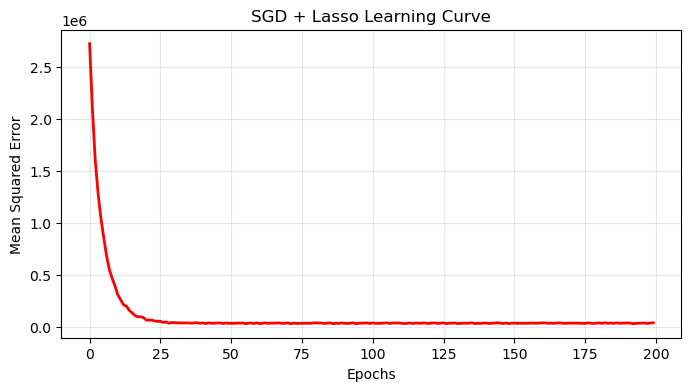

In [6]:
model = SGDLassoRegression(alpha=150.0, learning_rate=0.01, epochs=200)
model.fit(X_scaled, y_data)

print(f"Final Bias (Base Price): ${model.bias:.2f}\n")

feature_names = ['CPU', 'RAM', 'GPU', 'Stickers']
print(f"{'Feature':<10} | {'Impact on Price'}")
print("-" * 30)
for name, weight in zip(feature_names, model.weights):
    print(f"{name:<10} | ${weight:.2f}")

# Plotting the Loss Curve
plt.figure(figsize=(8, 4))
plt.plot(range(model.epochs), model.loss_history, color='red', linewidth=2)
plt.title('SGD + Lasso Learning Curve')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error')
plt.grid(True, alpha=0.3)
plt.show()